# Equities

## Exercise 1: Calculating Returns

In [2]:
with open("../data/equity_data.xlsx", "r") as f:
    data = f.readlines()
data

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x98 in position 15: invalid start byte

In [ ]:
import pandas as pd

appl_price = pd.read_excel("../data/equity_data.xlsx", sheet_name="prices AAPL")
appl_corpacts = pd.read_excel("../data/equity_data.xlsx", sheet_name="dividends AAPL")


In [ ]:
appl_corpacts.columns

Index(['record_date', 'declared_date', 'ex_date', 'payable_date',
       'dividend_amount', 'dividend_frequency', 'dividend_type'],
      dtype='str')

In [ ]:
dates = appl_corpacts.loc[appl_corpacts['dividend_type']=="Regular Cash", 'ex_date']
amounts = appl_corpacts.loc[appl_corpacts['dividend_type']=="Regular Cash", 'dividend_amount']

In [ ]:
appl_price.columns

Index(['date', 'Adjusted Price', 'Unadjusted Price'], dtype='str')

In [ ]:
list(appl_price.index[appl_price["date"]==dates[0]])[0]

5623

In [ ]:
full_df = pd.merge(appl_price, appl_corpacts, how="outer", left_on="date", right_on="ex_date").sort_values("date", ascending=False).reset_index(drop=True)

In [ ]:
full_df["shift_adj_price"] = full_df["Adjusted Price"].shift(-1)
full_df["shift_unadj_price"] = full_df["Unadjusted Price"].shift(-1)
full_df.head()

,date,Adjusted Price,Unadjusted Price,record_date,declared_date,ex_date,payable_date,dividend_amount,dividend_frequency,dividend_type,shift_adj_price,shift_unadj_price
0,2026-06-09,290.55,290.55,NaT,NaT,NaT,NaT,NaN,NaN,NaN,301.54,301.54
1,2026-06-08,301.54,301.54,NaT,NaT,NaT,NaT,NaN,NaN,NaN,307.34,307.34
2,2026-06-05,307.34,307.34,NaT,NaT,NaT,NaT,NaN,NaN,NaN,311.23,311.23
3,2026-06-04,311.23,311.23,NaT,NaT,NaT,NaT,NaN,NaN,NaN,310.26,310.26
4,2026-06-03,310.26,310.26,NaT,NaT,NaT,NaT,NaN,NaN,NaN,315.20,315.20


In [ ]:
full_df.loc[~full_df["ex_date"].isna()].head()
man_ret_div = (full_df.loc[~full_df["ex_date"].isna(), ["Unadjusted Price", "dividend_amount"]].sum(axis=1) / full_df.loc[~full_df["ex_date"].isna(), "shift_unadj_price"])-1
adj_ret_div = (full_df.loc[~full_df["ex_date"].isna(), "Adjusted Price"] / full_df.loc[~full_df["ex_date"].isna(), "shift_adj_price"])-1

print(man_ret_div.head(), "\n",  adj_ret_div.head())

20    -0.001261
83    -0.011650
144    0.004544
208   -0.008328
270    0.063064
dtype: float64 
 20    -0.001263
83    -0.011660
144    0.004548
208   -0.008337
270    0.063147
dtype: float64


In [ ]:
man_return = []
adj_return = []
for amount, date in list(zip(amounts, dates))[:2]:
    loc = list(appl_price.index[appl_price["date"]==date])[0]
    man_ret = (appl_price['Unadjusted Price'].iloc[loc]+amount)/appl_price['Unadjusted Price'].iloc[loc-1] if loc > 0 else 0
    man_return.append(round(man_ret,5))
    adj_ret = (appl_price['Adjusted Price'].iloc[loc])/appl_price['Adjusted Price'].iloc[loc-1] if loc > 0 else 0
    adj_return.append(round(adj_ret,5))
    rounds+=1

In [ ]:
print(man_return, adj_return)

[np.float64(0.99874), np.float64(0.98835)] [np.float64(0.99874), np.float64(0.98834)]


In [ ]:
appl_corpacts.columns

Index(['record_date', 'declared_date', 'ex_date', 'payable_date',
       'dividend_amount', 'dividend_frequency', 'dividend_type'],
      dtype='str')

In [ ]:
appl_corpacts["dividend_type"].unique()

<StringArray>
['Regular Cash', 'Stock Split', 'Discontinued']
Length: 3, dtype: str

In [ ]:
split_events = appl_corpacts.loc[appl_corpacts["dividend_type"]=="Stock Split", :].reset_index(drop=True)

In [ ]:
split_events

,record_date,declared_date,ex_date,payable_date,dividend_amount,dividend_frequency,dividend_type
0,2020-08-24,2020-07-30,2020-08-31,2020-08-28,4.0,NaN,Stock Split
1,2014-06-02,2014-04-23,2014-06-09,2014-06-06,7.0,NaN,Stock Split
2,2005-02-18,2005-02-11,2005-02-28,2005-02-25,2.0,NaN,Stock Split
3,2000-05-19,2000-04-19,2000-06-21,2000-06-20,2.0,NaN,Stock Split
4,1987-05-15,1987-04-22,1987-06-16,1987-06-15,2.0,NaN,Stock Split


In [ ]:
pos = list(appl_price.index[appl_price["date"]==split_events.loc[0, "ex_date"]])[0]

In [ ]:
man_ret_split = appl_price.loc[pos, "Unadjusted Price"]*split_events.loc[0, "dividend_amount"]/appl_price.loc[pos-1, "Unadjusted Price"]
adj_ret_split = appl_price.loc[pos, "Adjusted Price"]/appl_price.loc[pos-1, "Adjusted Price"]
print(man_ret_split, adj_ret_split)

1.0339122248262322 1.0339120256599397


In [ ]:
full_df.loc[full_df["dividend_type"]=="Stock Split"].dropna(subset=["date"])

split_events = full_df.loc[full_df["dividend_type"]=="Stock Split"].dropna(subset=["date"])
man_ret_split = split_events["Unadjusted Price"]*split_events["dividend_amount"]/split_events["shift_unadj_price"]
adj_ret_split = split_events["Adjusted Price"]/split_events["shift_adj_price"]
pd.concat([man_ret_split, adj_ret_split], axis=1).rename(columns={0:"manual", 1:"adjusted"})

,manual,adjusted
1449,1.033912,1.033912
3018,1.016001,1.016000
5353,1.008203,1.008183


## Exercise 2: Stock Sensiticity

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
etf_df = pd.read_excel("../data/equity_data.xlsx", sheet_name="etf history")
etf_df.head()

,date,SPY,UPRO,EEM,VGK,EWJ,IYR,DBC,HYG,TIP,BITO
0,1993-01-29,24.1807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-02-01,24.3527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-02-02,24.4043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-02-03,24.6622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-02-04,24.7654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
etf_df = etf_df.set_index("date", drop=True)
etf_df.head()

,SPY,UPRO,EEM,VGK,EWJ,IYR,DBC,HYG,TIP,BITO
date,,,,,,,,,,
1993-01-29,24.1807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,24.3527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,24.4043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,24.6622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,24.7654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
etf_df.corr()

,SPY,UPRO,EEM,VGK,EWJ,IYR,DBC,HYG,TIP,BITO
SPY,1.000000,0.977206,0.811212,0.967546,0.931607,0.916068,0.008005,0.925156,0.838004,0.823945
UPRO,0.977206,1.000000,0.881603,0.964347,0.953047,0.866270,0.232304,0.898436,0.838877,0.802206
EEM,0.811212,0.881603,1.000000,0.895941,0.861063,0.846201,0.085148,0.831568,0.861820,0.609855
VGK,0.967546,0.964347,0.895941,1.000000,0.974050,0.912418,0.056812,0.905470,0.804768,0.755894
EWJ,0.931607,0.953047,0.861063,0.974050,1.000000,0.914443,-0.038625,0.909381,0.773140,0.720431
IYR,0.916068,0.866270,0.846201,0.912418,0.914443,1.000000,-0.183142,0.965599,0.908332,0.632135
DBC,0.008005,0.232304,0.085148,0.056812,-0.038625,-0.183142,1.000000,-0.212230,-0.177535,0.016105
HYG,0.925156,0.898436,0.831568,0.905470,0.909381,0.965599,-0.212230,1.000000,0.956185,0.859987
TIP,0.838004,0.838877,0.861820,0.804768,0.773140,0.908332,-0.177535,0.956185,1.000000,0.642790
BITO,0.823945,0.802206,0.609855,0.755894,0.720431,0.632135,0.016105,0.859987,0.642790,1.000000


<Axes: >

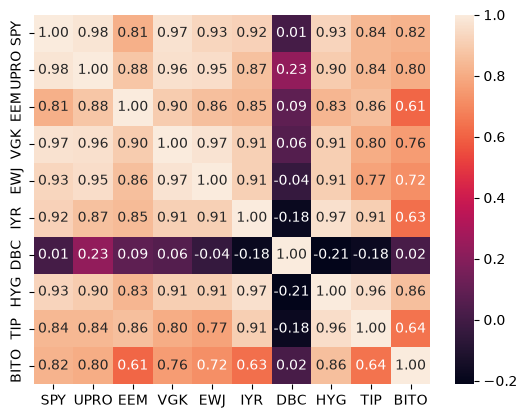

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(etf_df.corr(), annot=True, fmt=".2f")

In [ ]:
intersect = etf_df[["UPRO"]].index.intersection(etf_df["SPY"].index)
intersect

DatetimeIndex(['1993-01-29', '1993-02-01', '1993-02-02', '1993-02-03',
               '1993-02-04', '1993-02-05', '1993-02-08', '1993-02-09',
               '1993-02-10', '1993-02-11',
               ...
               '2026-05-27', '2026-05-28', '2026-05-29', '2026-06-01',
               '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05',
               '2026-06-08', '2026-06-09'],
              dtype='datetime64[us]', name='date', length=8397, freq=None)

In [ ]:
etf_df[["UPRO"]].dropna()

,UPRO
date,
2009-06-25,1.1324
2009-06-26,1.1265
2009-06-29,1.1585
2009-06-30,1.1308
2009-07-01,1.1429
...,...
2026-06-03,147.7200
2026-06-04,149.3300
2026-06-05,137.5300


In [ ]:
for col in etf_df.columns:
    model = LinearRegression()
    intersect = etf_df[[col]].dropna().index.intersection(etf_df["SPY"].dropna().index)
    model.fit(etf_df.loc[intersect, [col]], etf_df.loc[intersect, "SPY"]) # sklearn automatically add constant in front
    print(f"for {col}, the coefficients are {model.coef_}, and intercept is {model.intercept_}")

# this is wrong since what we're looking for is the model for returns

for SPY, the coefficients are [1.], and intercept is -1.1368683772161603e-13
for UPRO, the coefficients are [5.37070018], and intercept is 116.1942768661616
for EEM, the coefficients are [13.08241572], and intercept is -190.94460307530747
for VGK, the coefficients are [11.02065159], and intercept is -221.32020289725153
for EWJ, the coefficients are [10.77530375], and intercept is -245.59883826983588
for IYR, the coefficients are [5.84734409], and intercept is -85.9174490312804
for DBC, the coefficients are [0.26921821], and intercept is 237.4643985178439
for HYG, the coefficients are [11.23796862], and intercept is -330.6702201732494
for TIP, the coefficients are [8.20968874], and intercept is -445.1008305455431
for BITO, the coefficients are [22.24647101], and intercept is 310.36981537345997


In [ ]:
for col in etf_df.columns:
    model = LinearRegression()
    intersect = etf_df[[col]].pct_change().dropna().index.intersection(etf_df["SPY"].pct_change().dropna().index)
    model.fit(etf_df[[col]].pct_change().dropna().loc[intersect], etf_df["SPY"].pct_change().dropna().loc[intersect]) # sklearn automatically add constant in front
    print(f"for {col}, the coefficients are {model.coef_}, and intercept is {model.intercept_}")



for SPY, the coefficients are [1.], and intercept is 1.0299920638612292e-18
for UPRO, the coefficients are [0.33342151], and intercept is 6.501249707792161e-05
for EEM, the coefficients are [0.55182113], and intercept is 0.00021585073823159257
for VGK, the coefficients are [0.71237497], and intercept is 0.00023555964654963212
for EWJ, the coefficients are [0.55080262], and intercept is 0.000345595094295347
for IYR, the coefficients are [0.52281916], and intercept is 0.00014319496164289235
for DBC, the coefficients are [0.39180055], and intercept is 0.00043194679407427855
for HYG, the coefficients are [1.23310693], and intercept is 0.0002227646655589617
for TIP, the coefficients are [-0.29514373], and intercept is 0.0005260738849027107
for BITO, the coefficients are [0.13802201], and intercept is 0.0004878711213927478


# Trading Value Stocks

## Exercise 1: A value strategy

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
equity = pd.read_excel("../data/spx_data_weekly.xlsx", sheet_name="spx data", header=None)
equity.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1470,1471,1472,1473,1474,1475,1476,1477,1478,1479,1480,1481,1482,1483,1484,1485,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509
0,NaN,A,NaN,NaN,AAPL,NaN,NaN,ABBV,NaN,NaN,ABNB,NaN,NaN,ABT,NaN,NaN,ACGL,NaN,NaN,ACN,NaN,NaN,ADBE,NaN,NaN,ADI,NaN,NaN,ADM,NaN,NaN,ADP,NaN,NaN,ADSK,NaN,NaN,AEE,NaN,NaN,...,NaN,WSM,NaN,NaN,WST,NaN,NaN,WTW,NaN,NaN,WY,NaN,NaN,WYNN,NaN,NaN,XEL,NaN,NaN,XOM,NaN,NaN,XYL,NaN,NaN,XYZ,NaN,NaN,YUM,NaN,NaN,ZBH,NaN,NaN,ZBRA,NaN,NaN,ZTS,NaN,NaN
1,NaN,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,...,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO
2,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,NaN,NaN,NaN,40.0398,2.3976,21.4031,21.6742,NaN,11.8201,79.5735,2.5637,16.7603,80.75,NaN,112.3139,51.7688,3.0907,19.994,35.1247,3.1886,10.1537,63.3657,3.0932,21.9023,50.83,NaN,177.6291,27.731,5.9139,11.4361,...,11.5716,32.0426,2.1846,19.8911,55.0138,0.7998,30.4273,105.5725,3.1114,16.9448,20.727,5.5966,20.3073,89.654,2.2308,19.521,23.3096,5.4913,11.8564,51.9923,5.6162,9.3716,31.9904,1.7605,16.7363,NaN,NaN,NaN,53.5097,3.0649,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
4,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,NaN,NaN,NaN,40.4612,2.3726,21.6283,21.9975,NaN,11.9964,80.759,2.526,17.01,80.59,NaN,112.0914,49.461,3.2349,19.1027,34.085,3.2859,9.8532,63.9067,3.067,22.0892,52.51,NaN,183.5,28.1056,5.8351,11.5905,...,11.9497,32.4754,2.1555,20.1598,57.2794,0.7682,31.6803,105.8428,3.1034,16.9882,20.3689,5.695,19.9565,89.9657,2.2231,19.5888,23.828,5.3718,12.1201,51.417,5.6791,9.2679,30.8233,1.8272,16.1257,NaN,NaN,NaN,53.1064,3.0881,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441


In [11]:
equity.iloc[0] = equity.iloc[0].ffill()
cols = ["date" if equity.iloc[2, i]=="date" else equity.iloc[0, i]+"_"+equity.iloc[1, i] for i in range(equity.shape[1])]
equity.columns=cols
equity.drop([0,1,2], axis=0)

,date,A_PX_LAST,A_EQY_DVD_YLD_IND,A_PE_RATIO,AAPL_PX_LAST,AAPL_EQY_DVD_YLD_IND,AAPL_PE_RATIO,ABBV_PX_LAST,ABBV_EQY_DVD_YLD_IND,ABBV_PE_RATIO,ABNB_PX_LAST,ABNB_EQY_DVD_YLD_IND,ABNB_PE_RATIO,ABT_PX_LAST,ABT_EQY_DVD_YLD_IND,ABT_PE_RATIO,ACGL_PX_LAST,ACGL_EQY_DVD_YLD_IND,ACGL_PE_RATIO,ACN_PX_LAST,ACN_EQY_DVD_YLD_IND,ACN_PE_RATIO,ADBE_PX_LAST,ADBE_EQY_DVD_YLD_IND,ADBE_PE_RATIO,ADI_PX_LAST,ADI_EQY_DVD_YLD_IND,ADI_PE_RATIO,ADM_PX_LAST,ADM_EQY_DVD_YLD_IND,ADM_PE_RATIO,ADP_PX_LAST,ADP_EQY_DVD_YLD_IND,ADP_PE_RATIO,ADSK_PX_LAST,ADSK_EQY_DVD_YLD_IND,ADSK_PE_RATIO,AEE_PX_LAST,AEE_EQY_DVD_YLD_IND,AEE_PE_RATIO,...,WRB_PE_RATIO,WSM_PX_LAST,WSM_EQY_DVD_YLD_IND,WSM_PE_RATIO,WST_PX_LAST,WST_EQY_DVD_YLD_IND,WST_PE_RATIO,WTW_PX_LAST,WTW_EQY_DVD_YLD_IND,WTW_PE_RATIO,WY_PX_LAST,WY_EQY_DVD_YLD_IND,WY_PE_RATIO,WYNN_PX_LAST,WYNN_EQY_DVD_YLD_IND,WYNN_PE_RATIO,XEL_PX_LAST,XEL_EQY_DVD_YLD_IND,XEL_PE_RATIO,XOM_PX_LAST,XOM_EQY_DVD_YLD_IND,XOM_PE_RATIO,XYL_PX_LAST,XYL_EQY_DVD_YLD_IND,XYL_PE_RATIO,XYZ_PX_LAST,XYZ_EQY_DVD_YLD_IND,XYZ_PE_RATIO,YUM_PX_LAST,YUM_EQY_DVD_YLD_IND,YUM_PE_RATIO,ZBH_PX_LAST,ZBH_EQY_DVD_YLD_IND,ZBH_PE_RATIO,ZBRA_PX_LAST,ZBRA_EQY_DVD_YLD_IND,ZBRA_PE_RATIO,ZTS_PX_LAST,ZTS_EQY_DVD_YLD_IND,ZTS_PE_RATIO
3,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,NaN,NaN,NaN,40.0398,2.3976,21.4031,21.6742,NaN,11.8201,79.5735,2.5637,16.7603,80.75,NaN,112.3139,51.7688,3.0907,19.994,35.1247,3.1886,10.1537,63.3657,3.0932,21.9023,50.83,NaN,177.6291,27.731,5.9139,11.4361,...,11.5716,32.0426,2.1846,19.8911,55.0138,0.7998,30.4273,105.5725,3.1114,16.9448,20.727,5.5966,20.3073,89.654,2.2308,19.521,23.3096,5.4913,11.8564,51.9923,5.6162,9.3716,31.9904,1.7605,16.7363,NaN,NaN,NaN,53.5097,3.0649,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
4,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,NaN,NaN,NaN,40.4612,2.3726,21.6283,21.9975,NaN,11.9964,80.759,2.526,17.01,80.59,NaN,112.0914,49.461,3.2349,19.1027,34.085,3.2859,9.8532,63.9067,3.067,22.0892,52.51,NaN,183.5,28.1056,5.8351,11.5905,...,11.9497,32.4754,2.1555,20.1598,57.2794,0.7682,31.6803,105.8428,3.1034,16.9882,20.3689,5.695,19.9565,89.9657,2.2231,19.5888,23.828,5.3718,12.1201,51.417,5.6791,9.2679,30.8233,1.8272,16.1257,NaN,NaN,NaN,53.1064,3.0881,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441
5,2015-07-17 00:00:00,36.5253,1.0951,27.5633,28.9159,1.7983,13.3628,45.0183,4.5315,12.1268,NaN,NaN,NaN,40.6322,2.3627,21.7197,21.9658,NaN,11.9791,82.1488,2.4833,17.3027,82.1,NaN,114.1916,50.2249,3.1857,19.3977,34.6698,3.2305,10.0222,64.5887,3.0346,22.325,52.19,NaN,182.3818,28.3721,5.7803,11.7005,...,11.9688,32.4599,2.1565,20.1502,58.35,0.8226,32.2725,105.8653,3.1028,16.9918,19.8416,5.8463,19.4399,88.0694,2.2709,19.1759,23.9346,5.3479,12.1743,51.6609,5.6522,9.3119,31.1891,1.8058,16.317,NaN,NaN,NaN,51.5946,3.1786,17.7469,95.2028,0.9243,18.0356,114.18,NaN,153.875,43.656,0.7605,26.3064
6,2015-07-24 00:00:00,35.9402,1.113,27.1218,27.7737,1.8723,12.835,43.7898,4.6586,11.7959,NaN,NaN,NaN,41.5686,2.3094,22.2203,22.2732,NaN,12.1468,82.713,2.4664,17.4215,80.98,NaN,112.6338,47.0326,3.4019,18.1648,34.0706,3.2873,9.849,62.5426,3.1339,21.6178,51.78,NaN,180.949,27.7527,5.9093,11.445,...,11.973,31.5155,2.2211,19.5639,57.2679,0.8382,31.674,104.0183,3.1579,16.6953,19.3794,5.9857,18.9871,88.6929,2.255,19.3117,23.338,5.4846,11.8708,49.9912,5.841,9.0109,30.1614,1.8673,15.7794,NaN,NaN,NaN,50.9077,3.2215,17.5106,94.4589,0.9316,17.8947,110.89,NaN,149.4412,45.1995,0.7345,27.2365
7,2015-07-31 00:00:00,37.4396,1.0684,26.4603,27.0599,1.9217,12.5051,45.0312,4.5302,12.1303,NaN,NaN,NaN,41.2754,2.3258,22.0636,22.6187,NaN,12.3352,84.299,2.42,17.7556,81.99,NaN,114.0386,46.9039,3.4112,17.1718,34.2366,3.2714,9.897,62.5348,3.1343,21.615,50.58,NaN,176.8254,29.5894,5.5425,12.2025,...,11.835,32.8543,2.1306,20.067,57.3349,0.8372,31.7111,104.7165,3.1368,16.8074,19.9783,5.8063,19.5738,89.3856,2.2375,19.4625,24.6235,5.1983,12.5247,49.534

In [14]:
equity = equity.drop([0, 1, 2]).reset_index(drop=True)
equity.head()

,date,A_PX_LAST,A_EQY_DVD_YLD_IND,A_PE_RATIO,AAPL_PX_LAST,AAPL_EQY_DVD_YLD_IND,AAPL_PE_RATIO,ABBV_PX_LAST,ABBV_EQY_DVD_YLD_IND,ABBV_PE_RATIO,ABNB_PX_LAST,ABNB_EQY_DVD_YLD_IND,ABNB_PE_RATIO,ABT_PX_LAST,ABT_EQY_DVD_YLD_IND,ABT_PE_RATIO,ACGL_PX_LAST,ACGL_EQY_DVD_YLD_IND,ACGL_PE_RATIO,ACN_PX_LAST,ACN_EQY_DVD_YLD_IND,ACN_PE_RATIO,ADBE_PX_LAST,ADBE_EQY_DVD_YLD_IND,ADBE_PE_RATIO,ADI_PX_LAST,ADI_EQY_DVD_YLD_IND,ADI_PE_RATIO,ADM_PX_LAST,ADM_EQY_DVD_YLD_IND,ADM_PE_RATIO,ADP_PX_LAST,ADP_EQY_DVD_YLD_IND,ADP_PE_RATIO,ADSK_PX_LAST,ADSK_EQY_DVD_YLD_IND,ADSK_PE_RATIO,AEE_PX_LAST,AEE_EQY_DVD_YLD_IND,AEE_PE_RATIO,...,WRB_PE_RATIO,WSM_PX_LAST,WSM_EQY_DVD_YLD_IND,WSM_PE_RATIO,WST_PX_LAST,WST_EQY_DVD_YLD_IND,WST_PE_RATIO,WTW_PX_LAST,WTW_EQY_DVD_YLD_IND,WTW_PE_RATIO,WY_PX_LAST,WY_EQY_DVD_YLD_IND,WY_PE_RATIO,WYNN_PX_LAST,WYNN_EQY_DVD_YLD_IND,WYNN_PE_RATIO,XEL_PX_LAST,XEL_EQY_DVD_YLD_IND,XEL_PE_RATIO,XOM_PX_LAST,XOM_EQY_DVD_YLD_IND,XOM_PE_RATIO,XYL_PX_LAST,XYL_EQY_DVD_YLD_IND,XYL_PE_RATIO,XYZ_PX_LAST,XYZ_EQY_DVD_YLD_IND,XYZ_PE_RATIO,YUM_PX_LAST,YUM_EQY_DVD_YLD_IND,YUM_PE_RATIO,ZBH_PX_LAST,ZBH_EQY_DVD_YLD_IND,ZBH_PE_RATIO,ZBRA_PX_LAST,ZBRA_EQY_DVD_YLD_IND,ZBRA_PE_RATIO,ZTS_PX_LAST,ZTS_EQY_DVD_YLD_IND,ZTS_PE_RATIO
0,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,NaN,NaN,NaN,40.0398,2.3976,21.4031,21.6742,NaN,11.8201,79.5735,2.5637,16.7603,80.75,NaN,112.3139,51.7688,3.0907,19.994,35.1247,3.1886,10.1537,63.3657,3.0932,21.9023,50.83,NaN,177.6291,27.731,5.9139,11.4361,...,11.5716,32.0426,2.1846,19.8911,55.0138,0.7998,30.4273,105.5725,3.1114,16.9448,20.727,5.5966,20.3073,89.654,2.2308,19.521,23.3096,5.4913,11.8564,51.9923,5.6162,9.3716,31.9904,1.7605,16.7363,NaN,NaN,NaN,53.5097,3.0649,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
1,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,NaN,NaN,NaN,40.4612,2.3726,21.6283,21.9975,NaN,11.9964,80.759,2.526,17.01,80.59,NaN,112.0914,49.461,3.2349,19.1027,34.085,3.2859,9.8532,63.9067,3.067,22.0892,52.51,NaN,183.5,28.1056,5.8351,11.5905,...,11.9497,32.4754,2.1555,20.1598,57.2794,0.7682,31.6803,105.8428,3.1034,16.9882,20.3689,5.695,19.9565,89.9657,2.2231,19.5888,23.828,5.3718,12.1201,51.417,5.6791,9.2679,30.8233,1.8272,16.1257,NaN,NaN,NaN,53.1064,3.0881,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441
2,2015-07-17 00:00:00,36.5253,1.0951,27.5633,28.9159,1.7983,13.3628,45.0183,4.5315,12.1268,NaN,NaN,NaN,40.6322,2.3627,21.7197,21.9658,NaN,11.9791,82.1488,2.4833,17.3027,82.1,NaN,114.1916,50.2249,3.1857,19.3977,34.6698,3.2305,10.0222,64.5887,3.0346,22.325,52.19,NaN,182.3818,28.3721,5.7803,11.7005,...,11.9688,32.4599,2.1565,20.1502,58.35,0.8226,32.2725,105.8653,3.1028,16.9918,19.8416,5.8463,19.4399,88.0694,2.2709,19.1759,23.9346,5.3479,12.1743,51.6609,5.6522,9.3119,31.1891,1.8058,16.317,NaN,NaN,NaN,51.5946,3.1786,17.7469,95.2028,0.9243,18.0356,114.18,NaN,153.875,43.656,0.7605,26.3064
3,2015-07-24 00:00:00,35.9402,1.113,27.1218,27.7737,1.8723,12.835,43.7898,4.6586,11.7959,NaN,NaN,NaN,41.5686,2.3094,22.2203,22.2732,NaN,12.1468,82.713,2.4664,17.4215,80.98,NaN,112.6338,47.0326,3.4019,18.1648,34.0706,3.2873,9.849,62.5426,3.1339,21.6178,51.78,NaN,180.949,27.7527,5.9093,11.445,...,11.973,31.5155,2.2211,19.5639,57.2679,0.8382,31.674,104.0183,3.1579,16.6953,19.3794,5.9857,18.9871,88.6929,2.255,19.3117,23.338,5.4846,11.8708,49.9912,5.841,9.0109,30.1614,1.8673,15.7794,NaN,NaN,NaN,50.9077,3.2215,17.5106,94.4589,0.9316,17.8947,110.89,NaN,149.4412,45.1995,0.7345,27.2365
4,2015-07-31 00:00:00,37.4396,1.0684,26.4603,27.0599,1.9217,12.5051,45.0312,4.5302,12.1303,NaN,NaN,NaN,41.2754,2.3258,22.0636,22.6187,NaN,12.3352,84.299,2.42,17.7556,81.99,NaN,114.0386,46.9039,3.4112,17.1718,34.2366,3.2714,9.897,62.5348,3.1343,21.615,50.58,NaN,176.8254,29.5894,5.5425,12.2025,...,11.835,32.8543,2.1306,20.067,57.3349,0.8372,31.7111,104.7165,3.1368,16.8074,19.9783,5.8063,19.5738,89.3856,2.2375,19.4625,24.6235,5.1983,12.5247,49.534

In [18]:
# since it's a weekly data => 5 years would be 5*52
YEARS = 5
WEEKS_IN_YEAR = 52

equity.isna().sum(axis=0)

date                      0
A_PX_LAST                 0
A_EQY_DVD_YLD_IND         0
A_PE_RATIO                0
AAPL_PX_LAST              0
                       ... 
ZBRA_EQY_DVD_YLD_IND    575
ZBRA_PE_RATIO            25
ZTS_PX_LAST               0
ZTS_EQY_DVD_YLD_IND       0
ZTS_PE_RATIO              0
Length: 1510, dtype: int64

In [21]:
equity.shape

(575, 1510)

In [47]:
[((equity.shape[0]-
equity[equity.columns[equity.columns.str.contains("PX_LAST")]]
.isna().sum(axis=0))>(YEARS*WEEKS_IN_YEAR))]

[A_PX_LAST       True
 AAPL_PX_LAST    True
 ABBV_PX_LAST    True
 ABNB_PX_LAST    True
 ABT_PX_LAST     True
                 ... 
 XYZ_PX_LAST     True
 YUM_PX_LAST     True
 ZBH_PX_LAST     True
 ZBRA_PX_LAST    True
 ZTS_PX_LAST     True
 Length: 503, dtype: bool]

In [49]:
names_unprocessed = equity[equity.columns[equity.columns.str.contains("PX_LAST")]].columns[((equity.shape[0]-
equity[equity.columns[equity.columns.str.contains("PX_LAST")]]
.isna().sum(axis=0))>(YEARS*WEEKS_IN_YEAR))]

In [54]:
names_processed = names_unprocessed.str.strip().str.split("_").str[0]
names_processed = set(names_processed)

In [55]:
equity_df = pd.DataFrame()
for col in equity.columns:
    if col == "date" or col.split("_")[0] in names_processed:
        equity_df[col] = equity[col]

equity_df.head()

/var/folders/3r/xyjscdhs47s9jp5p2xqww8w80000gn/T/ipykernel_16603/1800584359.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  equity_df[col] = equity[col]


,date,A_PX_LAST,A_EQY_DVD_YLD_IND,A_PE_RATIO,AAPL_PX_LAST,AAPL_EQY_DVD_YLD_IND,AAPL_PE_RATIO,ABBV_PX_LAST,ABBV_EQY_DVD_YLD_IND,ABBV_PE_RATIO,ABNB_PX_LAST,ABNB_EQY_DVD_YLD_IND,ABNB_PE_RATIO,ABT_PX_LAST,ABT_EQY_DVD_YLD_IND,ABT_PE_RATIO,ACGL_PX_LAST,ACGL_EQY_DVD_YLD_IND,ACGL_PE_RATIO,ACN_PX_LAST,ACN_EQY_DVD_YLD_IND,ACN_PE_RATIO,ADBE_PX_LAST,ADBE_EQY_DVD_YLD_IND,ADBE_PE_RATIO,ADI_PX_LAST,ADI_EQY_DVD_YLD_IND,ADI_PE_RATIO,ADM_PX_LAST,ADM_EQY_DVD_YLD_IND,ADM_PE_RATIO,ADP_PX_LAST,ADP_EQY_DVD_YLD_IND,ADP_PE_RATIO,ADSK_PX_LAST,ADSK_EQY_DVD_YLD_IND,ADSK_PE_RATIO,AEE_PX_LAST,AEE_EQY_DVD_YLD_IND,AEE_PE_RATIO,...,WRB_PE_RATIO,WSM_PX_LAST,WSM_EQY_DVD_YLD_IND,WSM_PE_RATIO,WST_PX_LAST,WST_EQY_DVD_YLD_IND,WST_PE_RATIO,WTW_PX_LAST,WTW_EQY_DVD_YLD_IND,WTW_PE_RATIO,WY_PX_LAST,WY_EQY_DVD_YLD_IND,WY_PE_RATIO,WYNN_PX_LAST,WYNN_EQY_DVD_YLD_IND,WYNN_PE_RATIO,XEL_PX_LAST,XEL_EQY_DVD_YLD_IND,XEL_PE_RATIO,XOM_PX_LAST,XOM_EQY_DVD_YLD_IND,XOM_PE_RATIO,XYL_PX_LAST,XYL_EQY_DVD_YLD_IND,XYL_PE_RATIO,XYZ_PX_LAST,XYZ_EQY_DVD_YLD_IND,XYZ_PE_RATIO,YUM_PX_LAST,YUM_EQY_DVD_YLD_IND,YUM_PE_RATIO,ZBH_PX_LAST,ZBH_EQY_DVD_YLD_IND,ZBH_PE_RATIO,ZBRA_PX_LAST,ZBRA_EQY_DVD_YLD_IND,ZBRA_PE_RATIO,ZTS_PX_LAST,ZTS_EQY_DVD_YLD_IND,ZTS_PE_RATIO
0,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,NaN,NaN,NaN,40.0398,2.3976,21.4031,21.6742,NaN,11.8201,79.5735,2.5637,16.7603,80.75,NaN,112.3139,51.7688,3.0907,19.994,35.1247,3.1886,10.1537,63.3657,3.0932,21.9023,50.83,NaN,177.6291,27.731,5.9139,11.4361,...,11.5716,32.0426,2.1846,19.8911,55.0138,0.7998,30.4273,105.5725,3.1114,16.9448,20.727,5.5966,20.3073,89.654,2.2308,19.521,23.3096,5.4913,11.8564,51.9923,5.6162,9.3716,31.9904,1.7605,16.7363,NaN,NaN,NaN,53.5097,3.0649,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
1,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,NaN,NaN,NaN,40.4612,2.3726,21.6283,21.9975,NaN,11.9964,80.759,2.526,17.01,80.59,NaN,112.0914,49.461,3.2349,19.1027,34.085,3.2859,9.8532,63.9067,3.067,22.0892,52.51,NaN,183.5,28.1056,5.8351,11.5905,...,11.9497,32.4754,2.1555,20.1598,57.2794,0.7682,31.6803,105.8428,3.1034,16.9882,20.3689,5.695,19.9565,89.9657,2.2231,19.5888,23.828,5.3718,12.1201,51.417,5.6791,9.2679,30.8233,1.8272,16.1257,NaN,NaN,NaN,53.1064,3.0881,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441
2,2015-07-17 00:00:00,36.5253,1.0951,27.5633,28.9159,1.7983,13.3628,45.0183,4.5315,12.1268,NaN,NaN,NaN,40.6322,2.3627,21.7197,21.9658,NaN,11.9791,82.1488,2.4833,17.3027,82.1,NaN,114.1916,50.2249,3.1857,19.3977,34.6698,3.2305,10.0222,64.5887,3.0346,22.325,52.19,NaN,182.3818,28.3721,5.7803,11.7005,...,11.9688,32.4599,2.1565,20.1502,58.35,0.8226,32.2725,105.8653,3.1028,16.9918,19.8416,5.8463,19.4399,88.0694,2.2709,19.1759,23.9346,5.3479,12.1743,51.6609,5.6522,9.3119,31.1891,1.8058,16.317,NaN,NaN,NaN,51.5946,3.1786,17.7469,95.2028,0.9243,18.0356,114.18,NaN,153.875,43.656,0.7605,26.3064
3,2015-07-24 00:00:00,35.9402,1.113,27.1218,27.7737,1.8723,12.835,43.7898,4.6586,11.7959,NaN,NaN,NaN,41.5686,2.3094,22.2203,22.2732,NaN,12.1468,82.713,2.4664,17.4215,80.98,NaN,112.6338,47.0326,3.4019,18.1648,34.0706,3.2873,9.849,62.5426,3.1339,21.6178,51.78,NaN,180.949,27.7527,5.9093,11.445,...,11.973,31.5155,2.2211,19.5639,57.2679,0.8382,31.674,104.0183,3.1579,16.6953,19.3794,5.9857,18.9871,88.6929,2.255,19.3117,23.338,5.4846,11.8708,49.9912,5.841,9.0109,30.1614,1.8673,15.7794,NaN,NaN,NaN,50.9077,3.2215,17.5106,94.4589,0.9316,17.8947,110.89,NaN,149.4412,45.1995,0.7345,27.2365
4,2015-07-31 00:00:00,37.4396,1.0684,26.4603,27.0599,1.9217,12.5051,45.0312,4.5302,12.1303,NaN,NaN,NaN,41.2754,2.3258,22.0636,22.6187,NaN,12.3352,84.299,2.42,17.7556,81.99,NaN,114.0386,46.9039,3.4112,17.1718,34.2366,3.2714,9.897,62.5348,3.1343,21.615,50.58,NaN,176.8254,29.5894,5.5425,12.2025,...,11.835,32.8543,2.1306,20.067,57.3349,0.8372,31.7111,104.7165,3.1368,16.8074,19.9783,5.8063,19.5738,89.3856,2.2375,19.4625,24.6235,5.1983,12.5247,49.534

In [56]:
equity.shape

(575, 1510)

In [60]:
## an alternative method: two level indexing

equity2 = pd.read_excel("../data/spx_data_weekly.xlsx", sheet_name="spx data", header=None)
equity2.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1470,1471,1472,1473,1474,1475,1476,1477,1478,1479,1480,1481,1482,1483,1484,1485,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509
0,NaN,A,NaN,NaN,AAPL,NaN,NaN,ABBV,NaN,NaN,ABNB,NaN,NaN,ABT,NaN,NaN,ACGL,NaN,NaN,ACN,NaN,NaN,ADBE,NaN,NaN,ADI,NaN,NaN,ADM,NaN,NaN,ADP,NaN,NaN,ADSK,NaN,NaN,AEE,NaN,NaN,...,NaN,WSM,NaN,NaN,WST,NaN,NaN,WTW,NaN,NaN,WY,NaN,NaN,WYNN,NaN,NaN,XEL,NaN,NaN,XOM,NaN,NaN,XYL,NaN,NaN,XYZ,NaN,NaN,YUM,NaN,NaN,ZBH,NaN,NaN,ZBRA,NaN,NaN,ZTS,NaN,NaN
1,NaN,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,...,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO,PX_LAST,EQY_DVD_YLD_IND,PE_RATIO
2,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-03 00:00:00,36.1871,1.1054,27.308,28.2065,1.8435,13.035,43.5502,4.6843,11.7314,NaN,NaN,NaN,40.0398,2.3976,21.4031,21.6742,NaN,11.8201,79.5735,2.5637,16.7603,80.75,NaN,112.3139,51.7688,3.0907,19.994,35.1247,3.1886,10.1537,63.3657,3.0932,21.9023,50.83,NaN,177.6291,27.731,5.9139,11.4361,...,11.5716,32.0426,2.1846,19.8911,55.0138,0.7998,30.4273,105.5725,3.1114,16.9448,20.727,5.5966,20.3073,89.654,2.2308,19.521,23.3096,5.4913,11.8564,51.9923,5.6162,9.3716,31.9904,1.7605,16.7363,NaN,NaN,NaN,53.5097,3.0649,18.4056,95.8138,0.9184,18.1514,112.43,NaN,151.5166,44.1218,0.7525,26.5871
4,2015-07-10 00:00:00,36.0225,1.1104,27.1839,27.5016,1.8908,12.7092,44.2014,4.6152,11.9068,NaN,NaN,NaN,40.4612,2.3726,21.6283,21.9975,NaN,11.9964,80.759,2.526,17.01,80.59,NaN,112.0914,49.461,3.2349,19.1027,34.085,3.2859,9.8532,63.9067,3.067,22.0892,52.51,NaN,183.5,28.1056,5.8351,11.5905,...,11.9497,32.4754,2.1555,20.1598,57.2794,0.7682,31.6803,105.8428,3.1034,16.9882,20.3689,5.695,19.9565,89.9657,2.2231,19.5888,23.828,5.3718,12.1201,51.417,5.6791,9.2679,30.8233,1.8272,16.1257,NaN,NaN,NaN,53.1064,3.0881,18.2669,94.5917,0.9303,17.9199,109.75,NaN,147.9049,42.8888,0.7741,25.8441


In [78]:
ticker = equity2.iloc[0].ffill()
fields = equity2.iloc[1]

df = equity2.iloc[3:].copy()
df.columns = pd.MultiIndex.from_arrays([ticker, fields])
df = df.rename(columns={df.columns[0]: ("date", "date")})
df.head()

0                  nan        A  ...             ZTS         
1                  nan  PX_LAST  ... EQY_DVD_YLD_IND PE_RATIO
3  2015-07-03 00:00:00  36.1871  ...          0.7525  26.5871
4  2015-07-10 00:00:00  36.0225  ...          0.7741  25.8441
5  2015-07-17 00:00:00  36.5253  ...          0.7605  26.3064
6  2015-07-24 00:00:00  35.9402  ...          0.7345  27.2365
7  2015-07-31 00:00:00  37.4396  ...          0.7422  26.9558

[5 rows x 1510 columns]

In [79]:
cols = list(df.columns)
cols[0] = ("date", "date")
df.columns = pd.MultiIndex.from_tuples(cols)
df.head()

date        A  ...             ZTS         
                  date  PX_LAST  ... EQY_DVD_YLD_IND PE_RATIO
3  2015-07-03 00:00:00  36.1871  ...          0.7525  26.5871
4  2015-07-10 00:00:00  36.0225  ...          0.7741  25.8441
5  2015-07-17 00:00:00  36.5253  ...          0.7605  26.3064
6  2015-07-24 00:00:00  35.9402  ...          0.7345  27.2365
7  2015-07-31 00:00:00  37.4396  ...          0.7422  26.9558

[5 rows x 1510 columns]

In [84]:
keep = []
for ticker in df.columns.get_level_values(0).unique():
    if ticker == 'date':
        keep.append(ticker)
    else:
        if (df[(ticker, "PX_LAST")].notna().sum())>=(YEARS*WEEKS_IN_YEAR):
            keep.append(ticker)

processed_df = df[[col for col in df.columns if col[0] in keep]]
processed_df.head()


date        A  ...             ZTS         
                  date  PX_LAST  ... EQY_DVD_YLD_IND PE_RATIO
3  2015-07-03 00:00:00  36.1871  ...          0.7525  26.5871
4  2015-07-10 00:00:00  36.0225  ...          0.7741  25.8441
5  2015-07-17 00:00:00  36.5253  ...          0.7605  26.3064
6  2015-07-24 00:00:00  35.9402  ...          0.7345  27.2365
7  2015-07-31 00:00:00  37.4396  ...          0.7422  26.9558

[5 rows x 1468 columns]

In [85]:
processed_df.head()

date        A  ...             ZTS         
                  date  PX_LAST  ... EQY_DVD_YLD_IND PE_RATIO
3  2015-07-03 00:00:00  36.1871  ...          0.7525  26.5871
4  2015-07-10 00:00:00  36.0225  ...          0.7741  25.8441
5  2015-07-17 00:00:00  36.5253  ...          0.7605  26.3064
6  2015-07-24 00:00:00  35.9402  ...          0.7345  27.2365
7  2015-07-31 00:00:00  37.4396  ...          0.7422  26.9558

[5 rows x 1468 columns]

In [92]:
processed_df = processed_df.set_index(("date", "date"), drop=True)

In [123]:
# find the lowest pe across the panel

mask = processed_df.columns.get_level_values(1).isin(["PE_RATIO"])
pe_only = processed_df.loc[:, mask]
ticker_index = pe_only.min().argmin()
date = pe_only.iloc[:, ticker_index].argmin()
print(f"lowest PE for the entire panel from {pe_only.columns[ticker_index][0]}, at date {pe_only.index[date]}")
print(pe_only.iloc[date, ticker_index])

lowest PE for the entire panel from NRG, at date 2020-03-20 00:00:00
0.6336


In [ ]:
# easier way
import datetime as dt

col = pe_only.min().idxmin()
row = pe_only.loc[:, col].idxmin()
print(f"the ticker that has the lowest pe overtime is {col[0]}, at {row.date()}")
print(f"with PE ratio being {pe_only.loc[row, col]}")

the ticker that has the lowest pe overtime is NRG, at 2020-03-20
with PE ratio being 0.6336


(0.0, 100.0)

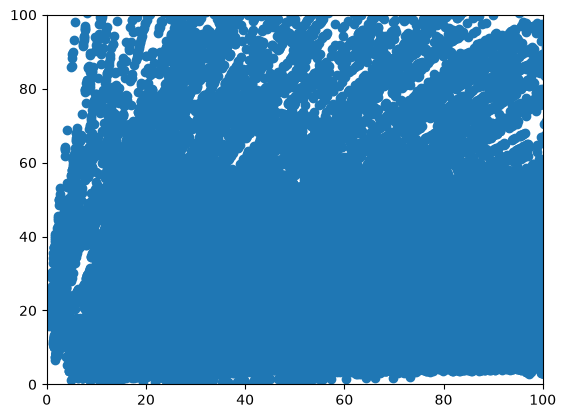

In [184]:
px_mask = processed_df.columns.get_level_values(1).isin(["PX_LAST"])
px_only = processed_df.loc[:, px_mask]
px_only.columns = px_only.columns.droplevel(1)
px_only = px_only.rename_axis(("date")).reset_index()
px_long = px_only.melt(id_vars="date", var_name="ticker", value_name="price")

# pe_only.columns = pe_only.columns.droplevel(1)
# pe_only = pe_only.rename_axis("date").reset_index()

pe_long = pe_only.melt(id_vars="date", var_name="ticker", value_name="pe")
pe_px_long = px_long.merge(pe_long, how="left", on=["date", "ticker"])

# since we know the date and ticker for the lowest PE, we can scatter the plot then highlight the point out
import matplotlib.pyplot as plt
plt.scatter(x=pe_px_long["price"], y=pe_px_long["pe"])
plt.xlim(xmin=0, xmax=100)
plt.ylim(ymin=0, ymax=100)

In [158]:
# lowest average over the past year

pe_num = pe_only.iloc[-252:].apply(pd.to_numeric, errors="coerce")
pe_num.mean().min()

np.float64(5.3907396825396825)